In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,accuracy_score,precision_recall_curve
)

In [10]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [14]:
x = df.drop("Class", axis=1)
y = df["Class"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
print("Training set fraud percentage:", y_train.mean()*100)
print("Test set fraud percentage:", y_test.mean()*100)

Training set fraud percentage: 0.17292457591783889
Test set fraud percentage: 0.17204452090867595


In [19]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [21]:
log_model = LogisticRegression(max_iter=1000,class_weight='balanced',random_state= 42)

In [22]:
log_model.fit(X_train,y_train)

c:\Users\sreer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [23]:
y_pred_log = log_model.predict(X_test)

In [25]:
print("Accuracy_score :",accuracy_score(y_test,y_pred_log))

Accuracy_score : 0.9728239879217724


In [27]:
print(confusion_matrix(y_test,y_pred_log))

[[55324  1540]
 [    8    90]]


In [28]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



## Model Evaluation

After training the Logistic Regression model, we evaluated its performance using **Accuracy, Confusion Matrix, and Classification Report**. Since the dataset is highly imbalanced, accuracy alone is not a reliable metric, so we analyze multiple evaluation metrics.

---

### Accuracy

Accuracy measures the proportion of correctly classified transactions.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

In this dataset, **fraud transactions represent only ~0.17% of all transactions**, meaning a model could achieve very high accuracy by simply predicting every transaction as normal. Therefore, accuracy does not reflect how well the model detects fraud.

---

### Confusion Matrix

The confusion matrix provides a detailed breakdown of predictions.

|                | Predicted Normal | Predicted Fraud |
|---------------|-----------------|----------------|
| **Actual Normal** | True Negative (TN) | False Positive (FP) |
| **Actual Fraud** | False Negative (FN) | True Positive (TP) |

From the model results:

- **True Negatives (TN): 55,324**  
- **False Positives (FP): 1,540**  
- **False Negatives (FN): 8**  
- **True Positives (TP): 90**

#### Interpretation

- The model correctly detected **90 fraudulent transactions**.
- **8 fraud transactions were missed**, which is critical because missed fraud results in financial loss.
- **1,540 normal transactions were incorrectly flagged as fraud**, which could inconvenience customers.

---

### Classification Report

The classification report provides **Precision, Recall, and F1-score** for each class.

| Metric | Meaning |
|------|------|
| **Precision** | Of all predicted fraud transactions, how many were actually fraud |
| **Recall** | Of all actual fraud transactions, how many were correctly detected |
| **F1-score** | Balance between precision and recall |

For the **fraud class (Class = 1)**:

- **Precision = 0.06**
- **Recall = 0.92**
- **F1-score = 0.10**

#### Interpretation

- The model detects **92% of fraud transactions**, which is very good.
- However, precision is low, meaning many predicted fraud transactions are actually normal transactions.
- This behavior is expected because the model was trained with **class weights to prioritize detecting fraud**, even at the cost of more false alarms.

---

### Key Insight

In fraud detection systems, **False Negatives are much more costly than False Positives**. Missing fraudulent transactions results in financial loss, whereas false alarms only inconvenience customers.

Because of this, the next step is to **optimize the classification threshold using a business cost function** to minimize total financial loss.

In [29]:
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [30]:
y_prob_log[:10]

array([1.36171180e-02, 6.01190795e-02, 1.62343471e-03, 1.05044445e-02,
       9.55681715e-01, 1.11114880e-02, 5.43228727e-04, 1.77650206e-02,
       7.97323415e-02, 4.41313208e-03])

In [32]:
thresholds = np.arange(0, 1, 0.01)
min_cost = float("inf")
best_threshold = 0
FN_cost = 10000
FP_cost = 100

In [36]:
for t in thresholds:
    y_prob_t = (y_prob_log >= t).astype('int')
    TN,FP,FN,TP = confusion_matrix(y_test,y_prob_t).ravel()
    total_cost = FN * FN_cost + FP * FP_cost
    if total_cost < min_cost:
        min_cost = total_cost
        best_threshold = t

print('Best Threshold :',best_threshold)
print('Minimum Coost :',min_cost)

Best Threshold : 0.97
Minimum Coost : 122700


In [37]:
y_pred_best = (y_prob_log >= best_threshold).astype(int)

confusion_matrix(y_test, y_pred_best)

array([[56737,   127],
       [   11,    87]])

In [39]:
# Default model predictions
y_pred_default = (y_prob_log >= 0.5).astype(int)

TN_d, FP_d, FN_d, TP_d = confusion_matrix(y_test, y_pred_default).ravel()

default_cost = FN_d * FN_cost + FP_d * FP_cost

print("Default Threshold Cost:", default_cost)

Default Threshold Cost: 234000


In [40]:
# Optimized model predictions
y_pred_best = (y_prob_log >= best_threshold).astype(int)

TN_b, FP_b, FN_b, TP_b = confusion_matrix(y_test, y_pred_best).ravel()

best_cost = FN_b * FN_cost + FP_b * FP_cost

print("Optimized Threshold Cost:", best_cost)

Optimized Threshold Cost: 122700


## Why Use `predict_proba()` Instead of `predict()`

After training the model, predictions can be generated using:

```python
y_pred_log = log_model.predict(X_test)
```

The `predict()` function directly returns the **final class labels (0 or 1)** based on the **default threshold of 0.5**. This means transactions with fraud probability ≥ 0.5 are classified as fraud, while others are classified as normal.

However, `predict()` does not provide the **underlying probability of fraud**, which limits our ability to adjust the decision threshold.

---

### Using `predict_proba()`

To obtain the probability of each transaction being fraudulent, we use:

```python
y_prob_log = log_model.predict_proba(X_test)[:,1]
```

`predict_proba()` returns the probability for both classes, and we select **column 1**, which represents the **probability of fraud**.

Having access to probabilities allows us to **modify the classification threshold** instead of relying on the default value of 0.5.

---

### Key Insight

Using `predict_proba()` enables **threshold optimization**, allowing the model to balance **false positives and false negatives** based on business objectives. This is especially important in fraud detection where **different thresholds lead to different financial outcomes**.

## Threshold Optimization Using Business Cost

In fraud detection, using the default classification threshold of **0.5** may not produce the best business outcome. Instead, we optimize the threshold using a **business cost function** that reflects the financial impact of prediction errors.

The cost function used in this project is:

Cost = (FN × 10000) + (FP × 100)

Where:

- **FN (False Negative)** → Fraud transactions missed by the model  
- **FP (False Positive)** → Normal transactions incorrectly flagged as fraud  

Missing fraud transactions leads to **significant financial loss**, so the cost of FN is much higher than FP.

---

### Searching for the Optimal Threshold

To find the best threshold, we evaluated multiple threshold values between **0 and 1** and calculated the total business cost for each threshold.

The threshold that **minimized the total business cost** was:

- **Best Threshold:** 0.97  
- **Minimum Cost:** 122,700  

---

### Model Comparison

To understand the impact of threshold optimization, we compare the **default model (threshold = 0.5)** with the **optimized model (threshold = 0.97)**.

| Metric | Default Model (0.5) | Optimized Model (0.97) |
|------|------|------|
| True Positives (TP) | 90 | 87 |
| False Positives (FP) | 1540 | 127 |
| False Negatives (FN) | 8 | 11 |
| Business Cost | 234,000 | 122,700 |

---

### Key Insight

- The optimized threshold **dramatically reduces false positives** (1540 → 127), meaning far fewer legitimate transactions are incorrectly blocked.
- Although false negatives increased slightly, the **overall business cost decreased significantly**.
- This demonstrates that adjusting the classification threshold can **align the model with real-world financial objectives** instead of relying on the default threshold.

# Random Forest

In [41]:
rf_model = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,n_jobs=-1)

In [42]:
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
y_pred_rf = rf_model.predict(X_test)

In [44]:
print(confusion_matrix(y_test,y_pred_rf))

[[56861     3]
 [   25    73]]


In [45]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [46]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [47]:
min_cost_rf = float("inf")
best_threshold_rf = 0

for t in thresholds:
    
    y_pred_t = (y_prob_rf >= t).astype(int)
    
    TN, FP, FN, TP = confusion_matrix(y_test, y_pred_t).ravel()
    
    total_cost = FN * FN_cost + FP * FP_cost
    
    if total_cost < min_cost_rf:
        min_cost_rf = total_cost
        best_threshold_rf = t

print("Best Threshold RF:", best_threshold_rf)
print("Minimum Cost RF:", min_cost_rf)

Best Threshold RF: 0.03
Minimum Cost RF: 112300


In [48]:
y_pred_rf_best = (y_prob_rf >= best_threshold_rf).astype(int)

confusion_matrix(y_test, y_pred_rf_best)

array([[56741,   123],
       [   10,    88]])

## Final Model Comparison

To determine the best model, we compare Logistic Regression and Random Forest after threshold optimization.

| Metric | Logistic Regression | Random Forest |
|------|------|------|
| Best Threshold | 0.97 | 0.03 |
| False Positives | 127 | 123 |
| False Negatives | 11 | 10 |
| True Positives | 87 | 88 |
| Business Cost | 122,700 | **112,300** |

### Conclusion

Both models improved significantly after threshold optimization. However, Random Forest achieved a lower total business cost.

- Random Forest slightly reduced both false positives and false negatives.
- This resulted in the **lowest financial loss** among the tested models.

Therefore, **Random Forest is selected as the final model for fraud detection in this project.**

# ROC Curve

In [49]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

In [50]:
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC Score:", auc_rf)

AUC Score: 0.952908497036969


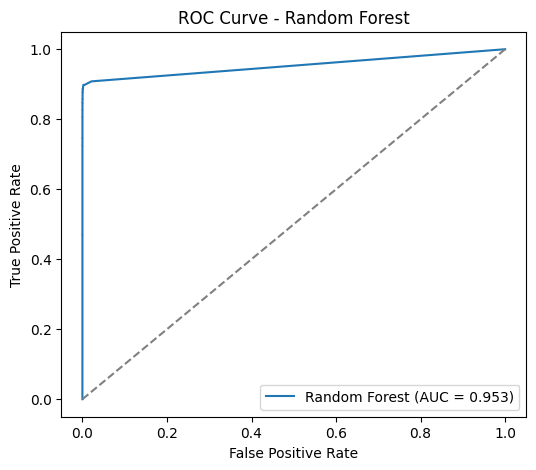

In [53]:
plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0,1],[0,1],'--',color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

### ROC Curve (Receiver Operating Characteristic)

The ROC curve evaluates how well the model separates fraudulent and normal transactions across different classification thresholds.  
It plots **True Positive Rate (Recall)** against **False Positive Rate**.  
A curve closer to the **top-left corner** indicates better model performance.  
The **AUC (Area Under Curve)** summarizes the model's ability to distinguish between the two classes.  
An AUC close to **1.0** indicates excellent discrimination between fraud and normal transactions.

# Feature Importance

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

best_features = feature_importance.head(10)

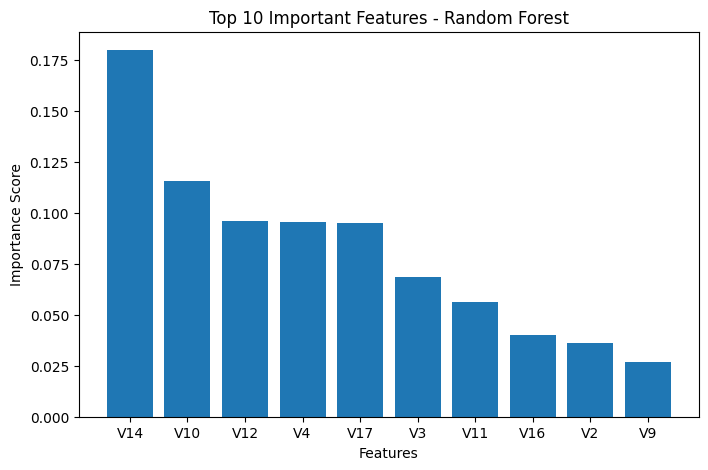

In [59]:
plt.figure(figsize=(8,5))

plt.bar(best_features["Feature"], best_features["Importance"])

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

### Feature Importance (Random Forest)

Feature importance shows how much each feature contributes to the model’s predictions.  
Random Forest calculates importance based on how much each feature improves decision splits across trees.  
Features with higher importance values have a **greater influence on fraud detection**.  
Since the dataset features (V1–V28) are **PCA-transformed components**, they represent transformed patterns rather than original variables.  
This analysis helps identify which components are most influential in detecting fraudulent transactions.

# PR Curve

In [62]:
precision_rf, recall_rf, thresholds_pr = precision_recall_curve(y_test, y_prob_rf)

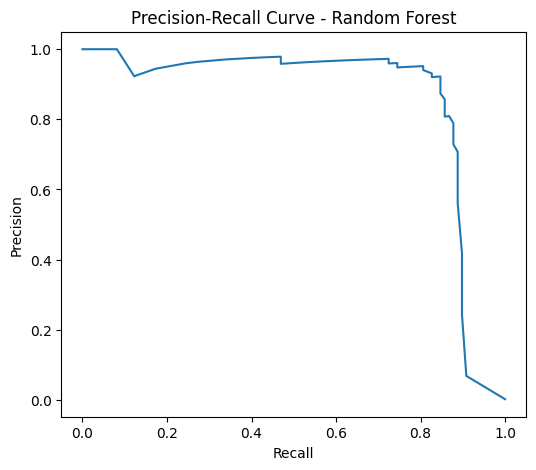

In [63]:
plt.figure(figsize=(6,5))

plt.plot(recall_rf, precision_rf)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")

plt.show()

### Precision-Recall Curve

The Precision–Recall curve illustrates the trade-off between **precision** and **recall** at different classification thresholds.  
Precision measures how many predicted fraud cases are actually fraud, while recall measures how many fraud cases were detected.  
This curve is especially useful for **imbalanced datasets**, where fraud transactions are very rare.  
A curve that remains closer to the **top-right region** indicates strong performance.  
It helps determine a threshold that balances fraud detection and false alerts.

## Project Conclusion

This project focused on detecting fraudulent credit card transactions using machine learning on a highly imbalanced dataset containing over **284,000 transactions**, where only **0.17% were fraudulent**. The main challenge was identifying fraud while minimizing financial loss caused by missed fraud cases and unnecessary transaction blocks.

Two models were evaluated: **Logistic Regression** and **Random Forest**. Logistic Regression achieved high recall but generated many false positives, meaning many legitimate transactions were incorrectly flagged as fraud. Random Forest produced much higher precision, reducing false alarms but initially missing more fraud cases.

To better align the model with real-world financial impact, a **cost-based threshold optimization** approach was applied using the formula:

Cost = (FN × 10000) + (FP × 100)

By adjusting the classification threshold, both models significantly reduced the overall business cost. After optimization, **Random Forest achieved the lowest total cost (112,300)** compared to Logistic Regression (122,700).

Based on this evaluation, **Random Forest was selected as the final model** because it provided the best balance between fraud detection and minimizing financial loss.

Overall, this project demonstrates how machine learning models can be optimized not only using standard evaluation metrics but also using **business-driven cost functions** to make more practical and impactful decisions in fraud detection systems.

## Key Insights

- The dataset is **highly imbalanced**, with fraud transactions representing only about **0.17%** of all transactions. This makes accuracy an unreliable metric for evaluating model performance.

- Logistic Regression achieved **high recall (0.92)** but produced many false positives, meaning a large number of legitimate transactions were incorrectly flagged as fraud.

- Random Forest achieved **very high precision (0.96)**, indicating that most transactions predicted as fraud were actually fraudulent.

- Applying **threshold optimization using a business cost function** significantly reduced the total financial loss compared to using the default classification threshold.

- After optimization, **Random Forest produced the lowest business cost**, making it the most suitable model for this fraud detection task.

- The project highlights the importance of **aligning machine learning models with business objectives**, rather than relying solely on traditional evaluation metrics.